# Weather & Pollution Relationship

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sqlalchemy import create_engine, text
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from matplotlib.patches import Patch

DB_USER = 'admin'
DB_PASS = 'admin'
DB_HOST = 'localhost'
DB_PORT = '5432'
DB_NAME = 'pap'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}',
    future=True
)

TARGET_POLLUTANTS = [
    'Biossido di Azoto',
    'PM10 (SM2005)',
    'Particelle sospese PM2.5',
    'Ozono',
]

TARGET_METEO = [
    'Velocità Vento',
    'Temperatura',
    'Umidità Relativa',
    'Radiazione Globale',
    'Precipitazione',
]

ALIASES_POLL = {
    'Biossido di Azoto': 'no2',
    'PM10 (SM2005)': 'pm10',
    'Particelle sospese PM2.5': 'pm25',
    'Ozono': 'o3',
}
ALIASES_METEO = {
    'Velocità Vento': 'wind',
    'Temperatura': 'temp',
    'Umidità Relativa': 'humidity',
    'Radiazione Globale': 'radiation',
    'Precipitazione': 'rain',
}

POLLUTANT_COLORS = {
    'no2': '#4393c3',
    'pm10': '#e6550d',
    'pm25': '#d73027',
    'o3': '#74c476',
}

POLLUTANT_LABELS = {
    'no2': 'NO2',
    'pm10': 'PM10',
    'pm25': 'PM2.5',
    'o3': 'O3',
}

POLLUTANTS = ['o3', 'no2', 'pm10', 'pm25']

IMGS_DIR = os.path.join('..', 'docs', 'images', '2_weather_pollution')
TABS_DIR = os.path.join('..', 'docs', 'tables', '2_weather_pollution')
os.makedirs(IMGS_DIR, exist_ok=True)
os.makedirs(TABS_DIR, exist_ok=True)


In [15]:
SQL_DAILY = """
SELECT
    d.date::date AS date,
    m.municipality_id,
    m.name AS municipality_name,
    se.name AS sensor_name,
    se.type AS sensor_type,
    AVG(sf.mean_value) AS value
FROM pap.sample_ft sf
JOIN pap.sensor_dt se ON se.sensor_id = sf.sensor_id
JOIN pap.station_dt st ON st.station_id = se.station_id
JOIN pap.municipality_dt m ON m.municipality_id = st.municipality_id
JOIN pap.date_dt d ON d.date_id = sf.date_id
WHERE d.year = 2023 AND se.name = ANY(:wanted)
GROUP BY d.date, m.municipality_id, m.name, se.name, se.type
ORDER BY d.date, m.municipality_id, se.name;
"""

wanted = TARGET_POLLUTANTS + TARGET_METEO
with engine.connect() as con:
    df_long = pd.read_sql(text(SQL_DAILY), con, params={'wanted': wanted})

df_long['date'] = pd.to_datetime(df_long['date'])

print(f"Total rows: {len(df_long):,}")
print(f"Date range: {df_long['date'].min().date()} → {df_long['date'].max().date()}")
print(f"Municipalities: {df_long['municipality_id'].nunique()}")

Total rows: 328,212
Date range: 2023-01-01 → 2023-12-31
Municipalities: 221


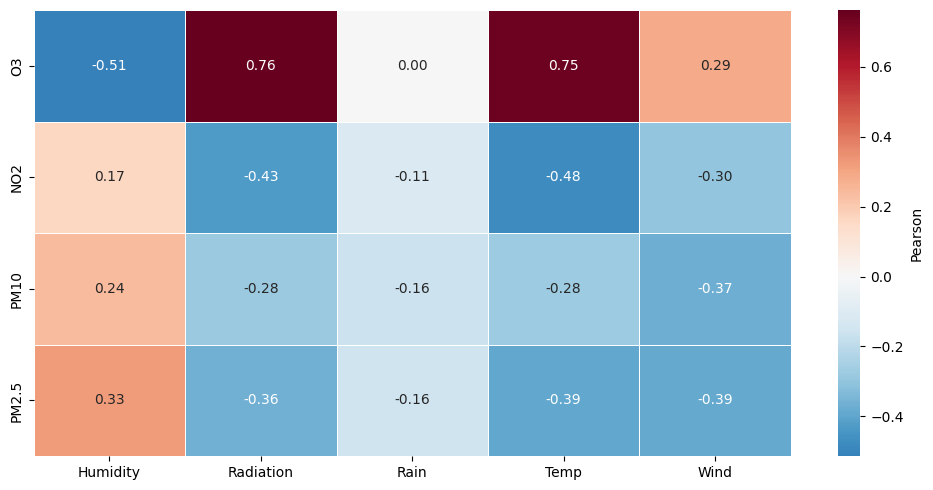

In [16]:

df_p = df_long[df_long['sensor_name'].isin(TARGET_POLLUTANTS)].copy()
df_p['pollutant'] = df_p['sensor_name'].map(ALIASES_POLL)
poll_wide = df_p.pivot_table(
    index=['municipality_id', 'municipality_name', 'date'],
    columns='pollutant', values='value', aggfunc='mean'
).reset_index()

df_m = df_long[df_long['sensor_name'].isin(TARGET_METEO)].copy()
df_m['meteo_var'] = df_m['sensor_name'].map(ALIASES_METEO)

meteo_wide = df_m.pivot_table(
    index=['municipality_id', 'municipality_name', 'date'],
    columns='meteo_var', values='value', aggfunc='mean'
).reset_index()

METEO_COLS = [c for c in meteo_wide.columns if c not in ['municipality_id', 'municipality_name', 'date']]

_check = pd.merge(
    meteo_wide[['municipality_id', 'date'] + METEO_COLS],
    poll_wide[['municipality_id', 'date'] + POLLUTANTS],
    on=['municipality_id', 'date'], how='inner'
)
corr_cols = METEO_COLS + POLLUTANTS
corr_mat = _check[corr_cols].corr().loc[POLLUTANTS, METEO_COLS]

poll_axis = [POLLUTANT_LABELS.get(p, p) for p in POLLUTANTS]
meteo_axis = [c.replace('_', ' ').title() for c in METEO_COLS]

plt.figure(figsize=(10, 5))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'label': 'Pearson'},
            xticklabels=meteo_axis, yticklabels=poll_axis)
plt.tight_layout()
plt.savefig(os.path.join(IMGS_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


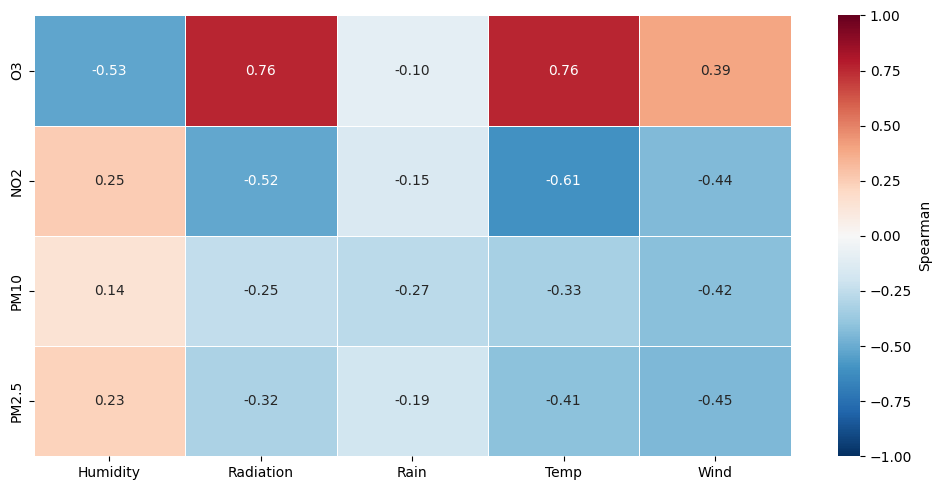

In [17]:

LMH_LABELS = ['LOW', 'MID', 'HIGH']
LMH_CODE = {'LOW': 1, 'MID': 2, 'HIGH': 3}

def per_munic_lmh_bins(df, col, group_col='municipality_id'):
    """Assign LOW/MID/HIGH based on per-municipality tertiles (33rd and 67th percentile)."""
    def _bin_group(s):
        s_valid = s.dropna()
        if len(s_valid) < 3:
            return pd.Series(np.nan, index=s.index)
        p33 = np.nanpercentile(s_valid, 100 / 3)
        p67 = np.nanpercentile(s_valid, 200 / 3)
        eps = max(1e-12, 1e-9 * (s_valid.max() - s_valid.min() + 1.0))
        if p67 <= p33:
            p67 = p33 + eps

        def _to_lmh(v):
            if pd.isna(v):
                return np.nan
            if v <= p33:
                return 'LOW'
            elif v <= p67:
                return 'MID'
            else:
                return 'HIGH'

        return s.apply(_to_lmh)

    return df.groupby(group_col)[col].transform(_bin_group)

df_lmh = pd.merge(
    meteo_wide[['municipality_id', 'date'] + METEO_COLS],
    poll_wide[['municipality_id', 'date'] + POLLUTANTS],
    on=['municipality_id', 'date'],
    how='inner'
).dropna(how='all', subset=METEO_COLS + POLLUTANTS)

meteo_lmh = pd.DataFrame(index=df_lmh.index)
for v in METEO_COLS:
    meteo_lmh[v] = per_munic_lmh_bins(df_lmh, v)

poll_lmh = pd.DataFrame(index=df_lmh.index)
for p in POLLUTANTS:
    poll_lmh[p] = per_munic_lmh_bins(df_lmh, p)

corr_lmh = pd.DataFrame(index=POLLUTANTS, columns=METEO_COLS, dtype=float)
for p in POLLUTANTS:
    for v in METEO_COLS:
        pair = pd.DataFrame({'poll': poll_lmh[p], 'meteo': meteo_lmh[v]}).dropna()
        if len(pair) > 1:
            corr_lmh.loc[p, v] = pair['poll'].map(LMH_CODE).corr(
                pair['meteo'].map(LMH_CODE), method='spearman'
            )
        else:
            corr_lmh.loc[p, v] = np.nan

poll_axis = [POLLUTANT_LABELS.get(p, p) for p in POLLUTANTS]
meteo_axis = [c.replace('_', ' ').title() for c in METEO_COLS]

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_lmh,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Spearman'},
    xticklabels=meteo_axis,
    yticklabels=poll_axis,
    vmin=-1,
    vmax=1,
 )
plt.tight_layout()
plt.savefig(
    os.path.join(IMGS_DIR, 'correlation_heatmap_lmh.png'),
    dpi=150,
    bbox_inches='tight'
 )
plt.show()


# Association Rules Weather -> Pollutants

In [18]:

df_merge = pd.merge(
    meteo_wide[['municipality_id', 'date'] + METEO_COLS],
    poll_wide[['municipality_id', 'date'] + POLLUTANTS],
    on=['municipality_id', 'date'],
    how='inner'
).dropna(how='all', subset=METEO_COLS + POLLUTANTS)

print(f"Merged dataset: {len(df_merge):,} transactions (municipality x day)")

basket = pd.DataFrame(index=df_merge.index)
meteo_items, pol_items = [], []

METEO_CODES = {v: v.upper().replace(' ', '_') for v in METEO_COLS}
POLL_CODES = {p: p.upper() for p in POLLUTANTS}

for v in METEO_COLS:
    binned = per_munic_lmh_bins(df_merge, v)
    for lab in ['LOW', 'MID', 'HIGH']:
        col = f'{METEO_CODES[v]}_{lab}'
        basket[col] = (binned == lab)
        meteo_items.append(col)

for p in POLLUTANTS:
    binned = per_munic_lmh_bins(df_merge, p)
    for lab in ['LOW', 'MID', 'HIGH']:
        col = f'{POLL_CODES[p]}_{lab}'
        basket[col] = (binned == lab)
        pol_items.append(col)

basket = basket.fillna(False).astype(bool)
meteo_set = set(meteo_items)
pol_set = set(pol_items)

print(f"Basket: {basket.shape[0]:,} transactions x {basket.shape[1]} items")
display(basket.head())
print(f"Weather items: {len(meteo_items)}")
print(f"Pollutant items: {len(pol_items)}")

item_freq = basket.mean().sort_values(ascending=False)
print(f"Top-10 most frequent items:\n{item_freq.head(10).to_string()}")


Merged dataset: 15,386 transactions (municipality x day)
Basket: 15,386 transactions x 27 items


,HUMIDITY_LOW,HUMIDITY_MID,HUMIDITY_HIGH,RADIATION_LOW,RADIATION_MID,RADIATION_HIGH,RAIN_LOW,RAIN_MID,RAIN_HIGH,TEMP_LOW,...,O3_HIGH,NO2_LOW,NO2_MID,NO2_HIGH,PM10_LOW,PM10_MID,PM10_HIGH,PM25_LOW,PM25_MID,PM25_HIGH
0,False,False,False,False,False,False,False,False,True,True,...,False,True,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,True,True,...,False,True,False,False,False,True,False,False,False,False
2,False,False,False,False,False,False,False,False,True,True,...,False,True,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,True,False,True,...,False,True,False,False,False,True,False,False,False,False
4,False,False,False,False,False,False,True,False,False,True,...,False,True,False,False,False,False,True,False,False,False


Weather items: 15
Pollutant items: 12
Top-10 most frequent items:
RAIN_LOW         0.618419
NO2_LOW          0.330495
NO2_HIGH         0.329845
NO2_MID          0.328545
TEMP_LOW         0.308267
TEMP_HIGH        0.308007
TEMP_MID         0.306122
RAIN_HIGH        0.294034
HUMIDITY_LOW     0.277525
HUMIDITY_HIGH    0.276875


In [19]:
MIN_SUPPORT = 0.005
MIN_CONF = 0.20
MAX_LEN = 30
MIN_LIFT = 1.20
MIN_RULE_SUPPORT = 0.005
PARTICULATE_CODES = ['PM10', 'PM25']

def sort_rules(df):
    if df.empty:
        return df
    return df.sort_values(
        ['lift', 'confidence', 'support'], ascending=False
    ).reset_index(drop=True)

def set_to_text(items):
    return ' + '.join(sorted(items))

def is_weather_to_poll_combo(ant, con):
    ant = set(ant)
    con = set(con)
    return ant.issubset(meteo_set) and con.issubset(pol_set)

print('Mining frequent itemsets')
freq_items = apriori(
    basket,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_LEN,
    low_memory=True
).sort_values('support', ascending=False).reset_index(drop=True)
print(f'Frequent itemsets: {len(freq_items)}')

rules_all = association_rules(
    freq_items,
    num_itemsets=len(basket),
    metric='confidence',
    min_threshold=MIN_CONF
)

mask = rules_all.apply(
    lambda r: is_weather_to_poll_combo(r['antecedents'], r['consequents']), axis=1
)
weather_rules = rules_all[mask].copy()

weather_rules['antecedent'] = weather_rules['antecedents'].apply(set_to_text)
weather_rules['consequent'] = weather_rules['consequents'].apply(set_to_text)
weather_rules['n_antecedents'] = weather_rules['antecedents'].apply(len)
weather_rules['n_consequents'] = weather_rules['consequents'].apply(len)
weather_rules['rule'] = (
    weather_rules['antecedent']
    + ' -> '
    + weather_rules['consequent']
)
weather_rules = sort_rules(weather_rules)

base_count = len(weather_rules)
weather_rules = weather_rules[
    (weather_rules['lift'] >= MIN_LIFT)
    & (weather_rules['support'] >= MIN_RULE_SUPPORT)
] .copy()
weather_rules = sort_rules(weather_rules)

pollutant_rules = weather_rules.copy()

particulate_prefixes = tuple(f'{code}_' for code in PARTICULATE_CODES)
particulate_rules = pollutant_rules[
    pollutant_rules['consequents'].apply(
        lambda cs: any(i.startswith(particulate_prefixes) for i in cs)
    )
] .copy()
particulate_rules = sort_rules(particulate_rules)

print(f"Rules WEATHER -> POLLUTANTS (combinations) before thresholds: {base_count:,}")
print(f"Pollutant rules: {len(pollutant_rules):,}")
print(f"Particulate rules: {len(particulate_rules):,}")

Mining frequent itemsets
Frequent itemsets: 8277
Rules WEATHER -> POLLUTANTS (combinations) before thresholds: 3,549
Pollutant rules: 3,004
Particulate rules: 1,769


## Pollutant Rules

Pollutant rules


,antecedent,consequent,support,confidence,lift
0,RADIATION_MID + RAIN_LOW + TEMP_MID + WIND_LOW,O3_MID + PM10_HIGH,0.006434,0.370787,7.370699
1,RAIN_LOW + TEMP_HIGH + WIND_LOW,O3_HIGH + PM10_HIGH,0.007539,0.231076,6.903555
2,HUMIDITY_MID + RADIATION_MID + RAIN_LOW + WIND...,NO2_HIGH + O3_MID + PM10_HIGH,0.005654,0.216958,6.812469
3,HUMIDITY_MID + RAIN_LOW + TEMP_MID + WIND_LOW,O3_MID + PM10_HIGH,0.006239,0.338028,6.719511
4,HUMIDITY_MID + RADIATION_MID + WIND_LOW,NO2_HIGH + O3_MID + PM10_HIGH,0.005914,0.205418,6.450113
...,...,...,...,...,...
2999,HUMIDITY_HIGH + RADIATION_MID + TEMP_MID,NO2_LOW,0.009034,0.398281,1.205103
3000,RAIN_HIGH + WIND_MID,O3_MID,0.020278,0.328076,1.204432
3001,RAIN_LOW + TEMP_LOW + WIND_HIGH,NO2_HIGH + O3_LOW,0.007669,0.238384,1.202155
3002,HUMIDITY_HIGH + RAIN_HIGH,NO2_MID,0.057910,0.394422,1.200511


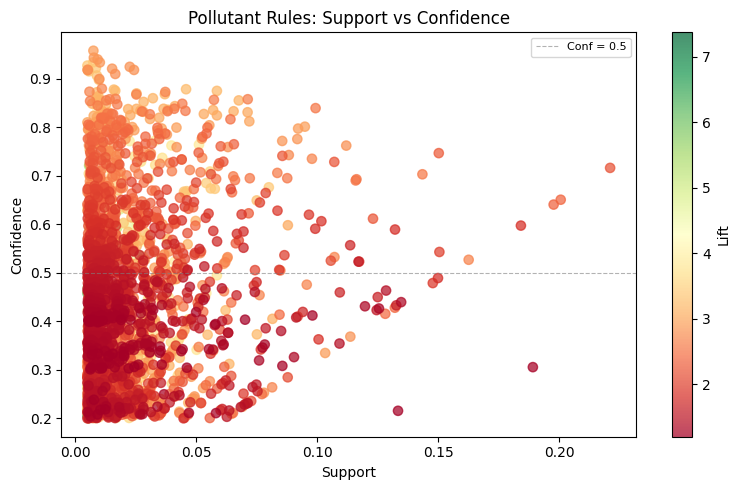

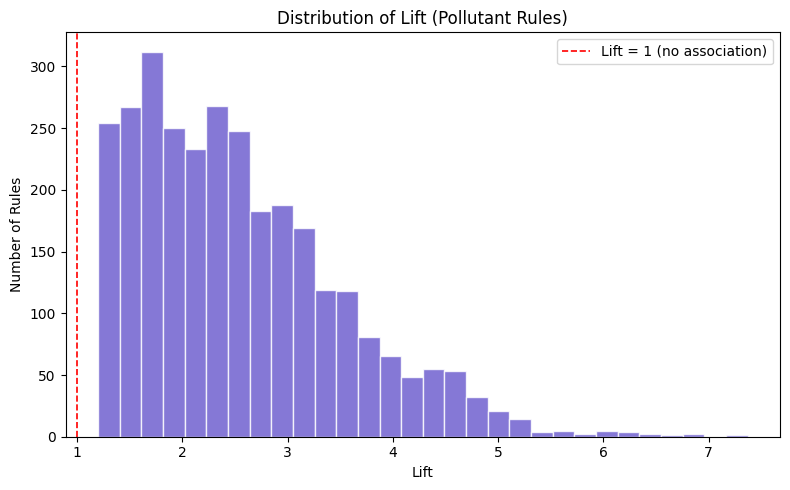

Pollutant Rules | Lift min: 1.20 mean: 2.54 max: 7.37


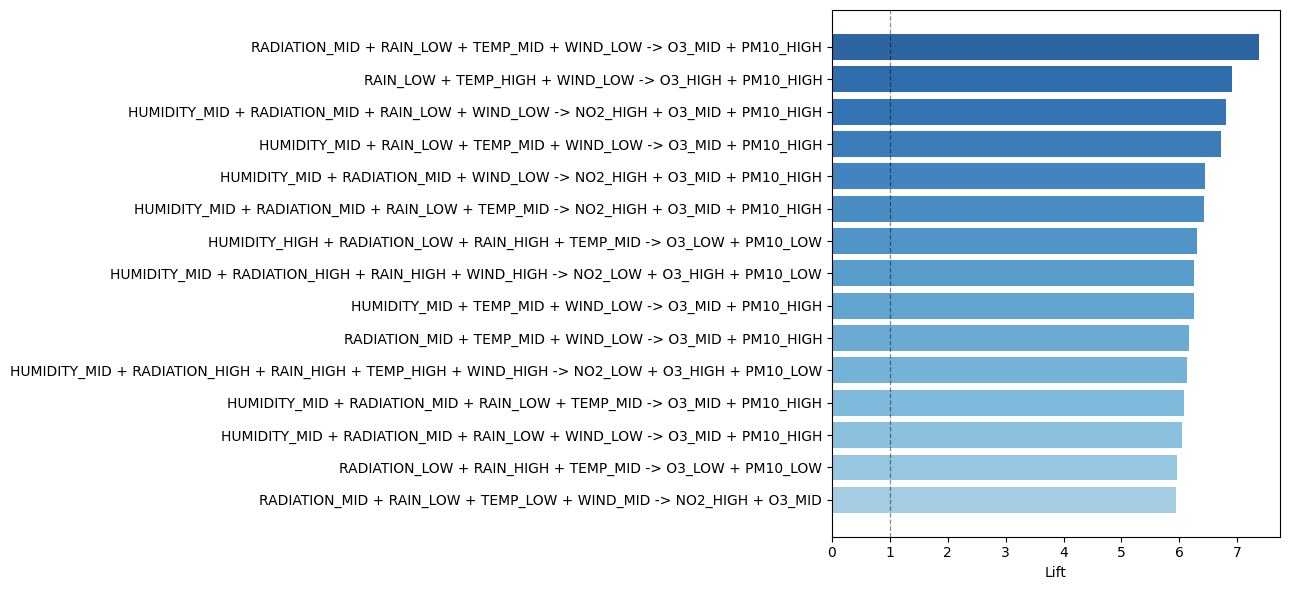

In [20]:
def plot_rules_charts(rules_df, title_prefix, hist_color='steelblue', save_dir=None, save_prefix=None):
    if rules_df.empty:
        print(f'No rules available for {title_prefix.lower()} charts.')
        return

    plt.figure(figsize=(8, 5))
    sc = plt.scatter(
        rules_df['support'],
        rules_df['confidence'],
        c=rules_df['lift'],
        cmap='RdYlGn',
        s=45,
        alpha=0.72,
    )
    plt.colorbar(sc, label='Lift')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.title(f'{title_prefix}: Support vs Confidence')
    plt.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='Conf = 0.5')
    plt.legend(fontsize=8)
    plt.tight_layout()
    if save_dir and save_prefix:
        plt.savefig(os.path.join(save_dir, f'{save_prefix}_support_confidence.png'), dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.hist(rules_df['lift'], bins=30, color=hist_color, alpha=0.82, edgecolor='white')
    plt.axvline(1.0, color='red', linestyle='--', linewidth=1.2, label='Lift = 1 (no association)')
    plt.xlabel('Lift')
    plt.ylabel('Number of Rules')
    plt.title(f'Distribution of Lift ({title_prefix})')
    plt.legend()
    plt.tight_layout()
    if save_dir and save_prefix:
        plt.savefig(os.path.join(save_dir, f'{save_prefix}_lift_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(
        f"{title_prefix} | Lift min: {rules_df['lift'].min():.2f} "
        f"mean: {rules_df['lift'].mean():.2f} max: {rules_df['lift'].max():.2f}"
    )

def plot_top_rules(rules_df, title, cmap_name='Reds', top_n=10, save_dir=None, save_prefix=None):
    if rules_df.empty:
        print(f'No rules available for {title.lower()}.')
        return

    top_chart = rules_df.head(top_n).copy()

    plt.figure(figsize=(13, 6))
    colors = plt.get_cmap(cmap_name)(np.linspace(0.4, 0.9, len(top_chart)))
    plt.barh(top_chart['rule'], top_chart['lift'], color=colors[::-1], alpha=0.85)
    plt.gca().invert_yaxis()
    plt.xlabel('Lift')
    plt.axvline(1.0, color='black', linestyle='--', linewidth=0.9, alpha=0.45)
    plt.tight_layout()
    if save_dir and save_prefix:
        plt.savefig(os.path.join(save_dir, f'{save_prefix}_top_rules.png'), dpi=150, bbox_inches='tight')
    plt.show()

print('Pollutant rules')
display(pollutant_rules[['antecedent', 'consequent', 'support', 'confidence', 'lift']])
pollutant_rules[['antecedent', 'consequent', 'support', 'confidence', 'lift']].to_csv(
    os.path.join(TABS_DIR, 'pollutant_rules.csv'), index=False
)
plot_rules_charts(pollutant_rules, 'Pollutant Rules', hist_color='slateblue',
                  save_dir=IMGS_DIR, save_prefix='pollutant_rules')
plot_top_rules(pollutant_rules, 'Weather Conditions -> Pollutants', cmap_name='Blues', top_n=15,
               save_dir=IMGS_DIR, save_prefix='pollutant_rules')


## Particulate Rules

Particulate rules


,antecedent,consequent,support,confidence,lift
0,RADIATION_MID + RAIN_LOW + TEMP_MID + WIND_LOW,O3_MID + PM10_HIGH,0.006434,0.370787,7.370699
1,RAIN_LOW + TEMP_HIGH + WIND_LOW,O3_HIGH + PM10_HIGH,0.007539,0.231076,6.903555
2,HUMIDITY_MID + RADIATION_MID + RAIN_LOW + WIND...,NO2_HIGH + O3_MID + PM10_HIGH,0.005654,0.216958,6.812469
3,HUMIDITY_MID + RAIN_LOW + TEMP_MID + WIND_LOW,O3_MID + PM10_HIGH,0.006239,0.338028,6.719511
4,HUMIDITY_MID + RADIATION_MID + WIND_LOW,NO2_HIGH + O3_MID + PM10_HIGH,0.005914,0.205418,6.450113
...,...,...,...,...,...
1764,RAIN_HIGH + TEMP_HIGH + WIND_MID,PM10_MID,0.006369,0.304348,1.214077
1765,RADIATION_HIGH + WIND_HIGH,PM10_MID,0.022033,0.302949,1.208497
1766,HUMIDITY_LOW + TEMP_HIGH + WIND_HIGH,PM10_LOW,0.013714,0.328149,1.205853
1767,RAIN_LOW,NO2_HIGH + PM10_HIGH,0.133303,0.215554,1.205569


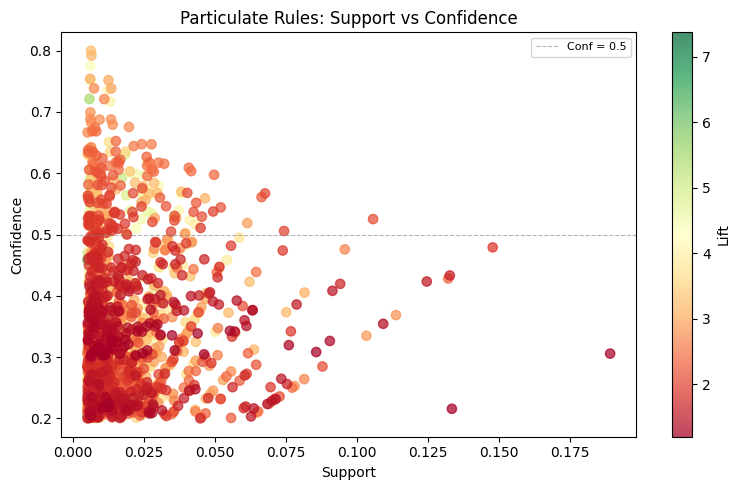

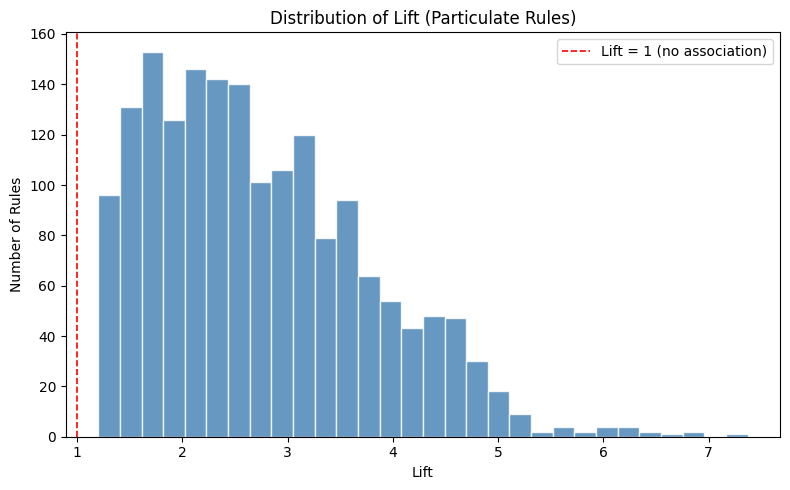

Particulate Rules | Lift min: 1.20 mean: 2.75 max: 7.37


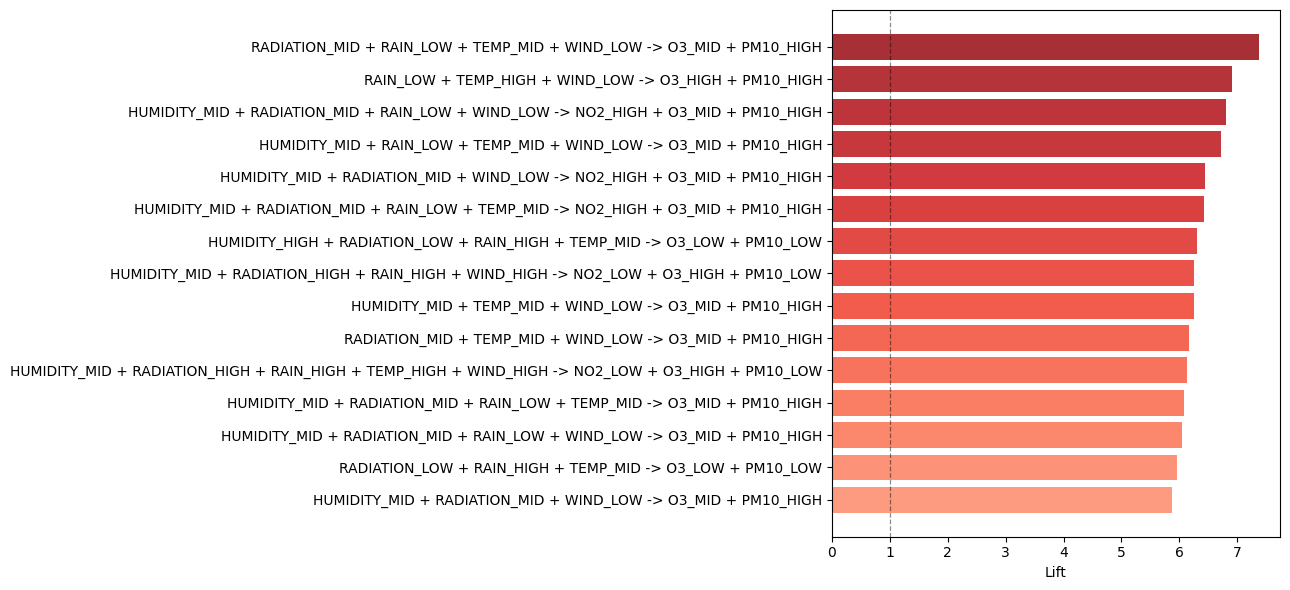

In [21]:
print('Particulate rules')
display(particulate_rules[['antecedent', 'consequent', 'support', 'confidence', 'lift']])
particulate_rules[['antecedent', 'consequent', 'support', 'confidence', 'lift']].to_csv(
    os.path.join(TABS_DIR, 'particulate_rules.csv'), index=False
)
plot_rules_charts(particulate_rules, 'Particulate Rules', hist_color='steelblue',
                  save_dir=IMGS_DIR, save_prefix='particulate_rules')
plot_top_rules(particulate_rules, 'Weather Conditions -> Particulate (PM10/PM25)', cmap_name='Reds', top_n=15,
               save_dir=IMGS_DIR, save_prefix='particulate_rules')
